<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/%D0%9C%D0%BD%D0%BE%D0%B6%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D0%B0%D1%8F_%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Преамбула

Предложенный набор данных содержит данные 49 штатов США по состоянию на 1950 г.:
- **State**: название штата
- **Ocean**: близость к морю
- **Lat**: широта
- **Long**: долгота
- **Mort**: смертность от рака кожи (количество смертей на 10 млн. населения)

# Задание 1

Необходимо научиться предсказывать значение смертности от рака кожи по значению [широты](https://ru.wikipedia.org/wiki/Широта).

1.   Загрузить датасет по адресу https://online.stat.psu.edu/stat462/sites/onlinecourses.science.psu.edu.stat462/files/data/skincancer/index.txt (Подсказка: для корректного прочтения файла используйте в функции read_csv аргумент sep="\s+")
2.   Отобразить краткую информацию о датасете
3.   Построить график зависимости смертности от широты, подписать график и оси координат
4.   Обучить модель линейной регрессии и визуализировать на графике зависимости смертности от широты прямую, харатеризующую обученную модель линейной регрессии
5.   Предоставить возможность пользователю ввести в поле ввода значение широты и вывести предсказанное значение смертности








In [ ]:
import pandas as pd

In [ ]:
url = 'https://online.stat.psu.edu/stat462/sites/onlinecourses.science.psu.edu.stat462/files/data/skincancer/index.txt'
# ваш код здесь

# Контрольные вопросы

## Вопрос 1:
Приведите примеры (2-3) проблем, которые могут быть решены при помощи регрессии?

## Ответ 1:
...

## Вопрос 2:
Сколько параметров в уравнении линейной регрессии? Опишите их смысл.

## Ответ 2:
...

#Задание 2

В данной части лабораторной работы предстоит решить задачу прогнозирования прибыли компании на основе её затрат с помощью множественной линейной регрессии.

Вам предоставлен датасет, содержащий информацию о 50 компаниях:

R&D Spend — расходы на исследования

Administration — административные расходы

Marketing Spend — расходы на маркетинг

State — штат (категориальный признак)

Profit — прибыль (целевая переменная)

Цель работы:
Построить модель множественной линейной регрессии и оценить её качество, учитывая как числовые, так и категориальные признаки.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
# импортируем dataset
dataset = pd.read_csv('https://gist.githubusercontent.com/GaneshSparkz/b5662effbdae8746f7f7d8ed70c42b2d/raw/faf8b1a0d58e251f48a647d3881e7a960c3f0925/50_Startups.csv')

In [ ]:
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


1. Проверьте данные на пропуски
2. Разделите данные на признаки и целевую переменную (X, y)
(модель должна предсказывать Profit)

In [ ]:
#1
dataset.isnull().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


In [ ]:
#2
X = dataset.drop('Profit', axis=1)

y = dataset['Profit']

print("Размер X:", X.shape)
print("Размер y:", y.shape)

Размер X: (50, 4)
Размер y: (50,)


Признак State является категориальным, поэтому его необходимо преобразовать в числовой вид.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["State"]

transformer = ColumnTransformer(
    [("one_hot", OneHotEncoder(), categorical_features)],
    remainder="passthrough"
)

X_transformed = transformer.fit_transform(X)

feature_names = transformer.get_feature_names_out()
print("Названия признаков после преобразования:")
print(feature_names)

Названия признаков после преобразования:
['one_hot__State_California' 'one_hot__State_Florida'
 'one_hot__State_New York' 'remainder__R&D Spend'
 'remainder__Administration' 'remainder__Marketing Spend']


3. Расскажите, как работает метод OneHotEncoder

- Определяет все уникальные значения в категориальном столбце (California, Florida, New York)

- Создает новый столбец для каждого значения

- Ставит 1 в том столбце, который соответствует категории объекта

- Ставит 0 во всех остальных столбцах

4. Постройте матрицу корреляций признаков

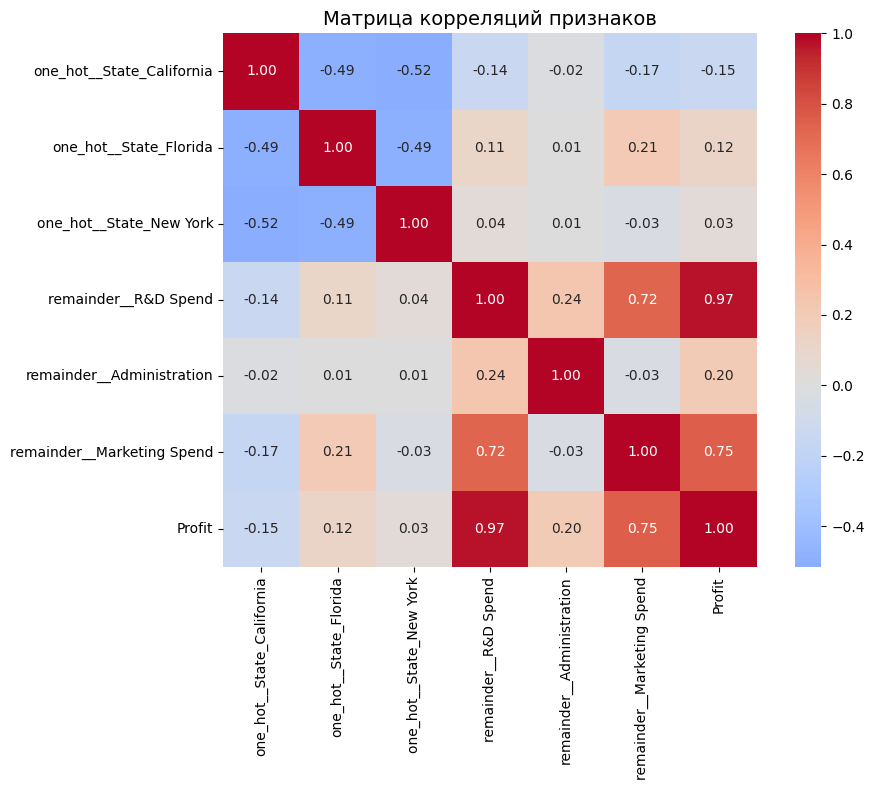


Корреляция признаков с прибылью (Profit):
remainder__R&D Spend          0.972900
remainder__Marketing Spend    0.747766
remainder__Administration     0.200717
one_hot__State_Florida        0.116244
one_hot__State_New York       0.031368
one_hot__State_California    -0.145837
Name: Profit, dtype: float64


In [ ]:
feature_names = transformer.get_feature_names_out()
X_df = pd.DataFrame(X_transformed, columns=feature_names)
X_df['Profit'] = y.values

plt.figure(figsize=(10, 8))
sns.heatmap(X_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Матрица корреляций признаков', fontsize=14)
plt.tight_layout()
plt.show()

print("\nКорреляция признаков с прибылью (Profit):")
print(X_df.corr()['Profit'].drop('Profit').sort_values(ascending=False))

5. Разделите данные на обучающую и тестовую выборку и обучите модель

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Коэффициенты модели (β):")
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.2f}")
print(f"\nСвободный член (intercept): {model.intercept_:.2f}")

Коэффициенты модели (β):
one_hot__State_California: -315.26
one_hot__State_Florida: 623.53
one_hot__State_New York: -308.27
remainder__R&D Spend: 0.81
remainder__Administration: -0.07
remainder__Marketing Spend: 0.03

Свободный член (intercept): 54343.30


6. Оцените качество модели с помощью model.score и получите предсказания с помощью model.predict

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

r2 = model.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² (коэффициент детерминации): {r2:.4f}")

print("\n=== Сравнение первых 5 тестовых примеров ===")
comparison = pd.DataFrame({
    'Реальная прибыль': y_test.values,
    'Предсказанная прибыль': y_pred,
    'Ошибка': y_test.values - y_pred
})
print(comparison.head())

print (f"Регрессия = {model.intercept_:.2f} + {model.coef_[0]:.2f} * State_California + {model.coef_[1]:.2f} * State_Florida + {model.coef_[2]:.2f} * State_New_York + {model.coef_[3]:.2f} * R&D + {model.coef_[4]:.2f} * Administration + {model.coef_[5]:.2f} * Marketing")

R² (коэффициент детерминации): 0.8987

=== Сравнение первых 5 тестовых примеров ===
   Реальная прибыль  Предсказанная прибыль        Ошибка
0         134307.35          126362.879083   7944.470917
1          81005.76           84608.453836  -3602.693836
2          99937.59           99677.494252    260.095748
3          64926.08           46357.460686  18568.619314
4         125370.37          128750.482885  -3380.112885
Регрессия = 54343.30 + -315.26 * State_California + 623.53 * State_Florida + -308.27 * State_New_York + 0.81 * R&D + -0.07 * Administration + 0.03 * Marketing
